In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
MODEL = "/kaggle/input/datasets/shubhkumarmishra/age-detection"

faceProto = MODEL + "/opencv_face_detector.pbtxt"
faceModel = MODEL + "/opencv_face_detector_uint8.pb"

ageProto = MODEL + "/age_deploy.prototxt"
ageModel = MODEL + "/age_net.caffemodel"

faceNet = cv2.dnn.readNet(faceModel, faceProto)
ageNet = cv2.dnn.readNet(ageModel, ageProto)

AGE_BUCKETS = [
    '(0-2)',
    '(4-6)',
    '(8-12)',
    '(15-20)',
    '(25-32)',
    '(38-43)',
    '(48-53)',
    '(60-100)'
]

print("Models loaded successfully")

Models loaded successfully


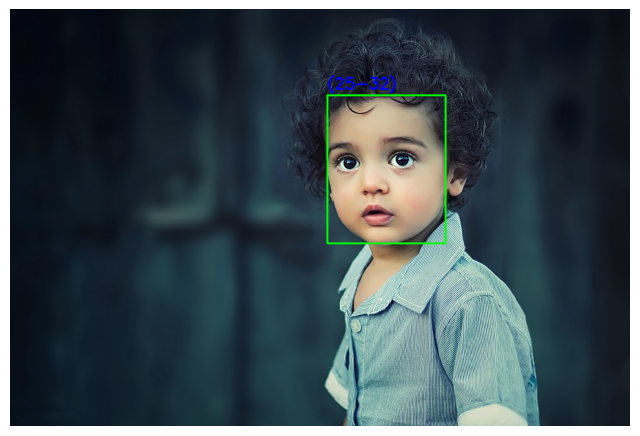

In [3]:
img = cv2.imread(
    "/kaggle/input/datasets/shubhkumarmishra/kid-image/kid1.jpg"
)

output = img.copy()

h, w = img.shape[:2]

blob = cv2.dnn.blobFromImage(
    img,
    1.0,
    (300,300),
    [104,117,123]
)

faceNet.setInput(blob)

detections = faceNet.forward()

AGE_BUCKETS = [
'(0-2)',
'(4-6)',
'(8-12)',
'(15-20)',
'(25-32)',
'(38-43)',
'(48-53)',
'(60-100)'
]

for i in range(detections.shape[2]):

    conf = detections[0,0,i,2]

    if conf > 0.7:

        box = detections[0,0,i,3:7]

        box = box * np.array(
            [w,h,w,h]
        )

        x1,y1,x2,y2 = box.astype(int)

        face = img[
            max(0,y1):min(y2,h),
            max(0,x1):min(x2,w)
        ]

        if face.size == 0:
            continue

        blob = cv2.dnn.blobFromImage(
            face,
            1.0,
            (227,227),
            (
                78.4,
                87.7,
                114.8
            ),
            swapRB=False
        )

        ageNet.setInput(blob)

        pred = ageNet.forward()

        age = AGE_BUCKETS[
            pred[0].argmax()
        ]

        cv2.rectangle(
            output,
            (x1,y1),
            (x2,y2),
            (0,255,0),
            2
        )

        cv2.putText(
            output,
            age,
            (x1,y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255,0,0),
            2
        )

plt.figure(
    figsize=(8,8)
)

plt.imshow(
    cv2.cvtColor(
        output,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")

plt.show()

In [4]:
import os

print(os.listdir("/kaggle/input"))

['datasets', 'notebooks']


In [5]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print("ROOT:", root)
    print("FILES SAMPLE:", files[:3])
    print("-----")

ROOT: /kaggle/input
FILES SAMPLE: []
-----
ROOT: /kaggle/input/datasets
FILES SAMPLE: []
-----
ROOT: /kaggle/input/datasets/shubhkumarmishra
FILES SAMPLE: []
-----
ROOT: /kaggle/input/datasets/shubhkumarmishra/age-detection
FILES SAMPLE: ['opencv_face_detector_uint8.pb', 'opencv_face_detector.pbtxt', 'age_deploy.prototxt']
-----
ROOT: /kaggle/input/datasets/shubhkumarmishra/kid-image
FILES SAMPLE: ['kid1.jpg']
-----
ROOT: /kaggle/input/datasets/shubhkumarmishra/signzip
FILES SAMPLE: []
-----
ROOT: /kaggle/input/datasets/shubhkumarmishra/signzip/UTKFace
FILES SAMPLE: ['26_0_2_20170104023102422.jpg.chip.jpg', '22_1_1_20170112233644761.jpg.chip.jpg', '21_1_3_20170105003215901.jpg.chip.jpg']
-----
ROOT: /kaggle/input/notebooks
FILES SAMPLE: []
-----
ROOT: /kaggle/input/notebooks/eward96
FILES SAMPLE: []
-----
ROOT: /kaggle/input/notebooks/eward96/age-and-gender-prediction-on-utkface
FILES SAMPLE: ['__results__.html', '__resultx__.html', '__notebook__.ipynb']
-----
ROOT: /kaggle/input/noteb

In [6]:
import os

print(os.listdir("/kaggle/input"))

['datasets', 'notebooks']


In [7]:
print(os.listdir("/kaggle/input/datasets/shubhkumarmishra"))

['age-detection', 'kid-image', 'signzip']


In [8]:
DATA = "/kaggle/input/datasets/shubhkumarmishra/signzip/UTKFace"

In [9]:
import os

print(os.listdir(DATA)[:5])

['26_0_2_20170104023102422.jpg.chip.jpg', '22_1_1_20170112233644761.jpg.chip.jpg', '21_1_3_20170105003215901.jpg.chip.jpg', '28_0_0_20170117180555824.jpg.chip.jpg', '17_1_4_20170103222931966.jpg.chip.jpg']


In [10]:
import cv2
import numpy as np

images = []
ages = []

for file in os.listdir(DATA):

    try:
        age = int(file.split("_")[0])

        img_path = os.path.join(DATA, file)

        img = cv2.imread(img_path)
        img = cv2.resize(img, (128,128))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        images.append(img)
        ages.append(age)

    except:
        pass

X = np.array(images)
y = np.array(ages)

print(X.shape, y.shape)

(23708, 128, 128, 3) (23708,)


In [11]:
X = X / 255.0

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(18966, 128, 128, 3) (4742, 128, 128, 3)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1))   # age output

model.compile(
    optimizer='adam',
    loss='mae'
)

model.summary()

2026-06-21 19:00:18.412214: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782068418.601611      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782068418.657822      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782068419.107575      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782068419.107620      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782068419.107623      23 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,516,289 (24.86 MB)

 Trainable params: 6,516,289 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

In [15]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False  # important

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1)(x)

model = Model(inputs=base_model.input, outputs=output)

In [17]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='mae'
)

In [18]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
import pandas as pd
import os

files = os.listdir(DATA)

df = pd.DataFrame(files, columns=['filename'])

df['age'] = df['filename'].apply(lambda x: int(x.split('_')[0]))

In [ ]:
train_gen = train_datagen.flow_from_dataframe(
    dataframe=df,
    directory=DATA,
    x_col="filename",
    y_col="age",
    target_size=(128,128),
    class_mode="raw",
    batch_size=32,
    subset="training"
)

In [ ]:
val_gen = train_datagen.flow_from_dataframe(
    dataframe=df,
    directory=DATA,
    x_col="filename",
    y_col="age",
    target_size=(128,128),
    class_mode="raw",
    batch_size=32,
    subset="validation"
)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

In [ ]:
model.save("age_model_mae7.keras")

In [ ]:
model.evaluate(val_gen)